# **Analysis multi run: P001S001 R02 to R05 - Inf -> Holding**

A generalized version of the single-run analysis. Each run is preprocessed independently (bad channel detection, filtering, average referencing, ICA), and the epochs from the four runs are then concatenated into a single `Epochs` object to run the cluster-based permutation test on the complete dataset.

The reason for separate preprocessing is that bad channels differ across runs (e.g., Fp2 in R04, and T8 in R03 and R05), and the average reference would be contaminated if calculated based on the raw concatenation.

After the ERP section the notebook follows three MNE protocols on the concatenated HOLDING epochs, plus the source PSD in a label:

1. [The Spectrum and EpochsSpectrum classes](https://mne.tools/stable/auto_tutorials/time-freq/10_spectrum_class.html)
2. [Compute source PSD in a label](https://mne.tools/stable/auto_examples/time_frequency/source_power_spectrum.html), one STC in dB per label and condition
3. [Frequency and time-frequency sensor analysis](https://mne.tools/stable/auto_tutorials/time-freq/20_sensors_time_frequency.html)
4. [Non-parametric between conditions cluster statistic on single trial power](https://mne.tools/stable/auto_tutorials/stats-sensor-space/50_cluster_between_time_freq.html), for none, low and high

In [1]:
%matplotlib inline

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import mne
from BCI2kReader import BCI2kReader as b2k
from autoreject import AutoReject
from mne.channels import find_ch_adjacency
from mne.datasets import fetch_fsaverage
from mne.minimum_norm import compute_source_psd_epochs, make_inverse_operator
from mne.stats import combine_adjacency, permutation_cluster_test
import warnings

warnings.filterwarnings("ignore")
mne.set_log_level("WARNING")

# **Settings**

In [2]:
# Root where all the ".dat" files are
ROOT = "/Users/alberto/Desktop/dat/Files"
# Name of all the P001 runs
RUNS = [
    "P001S001R02",
    "P001S001R03",
    "P001S001R04",
    "P001S001R05",
]

# PressureTarget in mmHg -> condition label
TARGET_MAP = {8: "none", 46: "low", 111: "high"}

# Stimulus Phase + 1, so HOLDING (phase 2) stays as event 3
EVENT_ID = {"hold": 3}

# Time that is going to be studied in ERP -0.5 to 9.5 seconds.
# The shortest holding window across the 120 trials is 10.00 s, so the
# epoch always fits inside the phase and never reaches the rating screen.
TMIN = -0.5
TMAX = 9.5
BASELINE = (-0.2, 0.0)

# Low and High Frequency Filters
L_FREQ = 0.1
H_FREQ = 40.0

"""¿Puedo bajar de 256 Hz a una frecuencia menor para hacer los cálculos más rápidos?"""
# The permutation test on 32 channels x 2561 samples is unnecessarily expensive.
# With DECIM = 3, the Nyquist frequency is 42.7 Hz, above the 40 Hz low-pass cutoff,
# so there is no aliasing. With DECIM = 4 the Nyquist would drop to 32 Hz and MNE warns.
DECIM = 3

# Z-score threshold used to identify bad or abnormal channels.
# Raised from 3.5 to 5.0. With 32 channels the MAD is small and 3.5 flags
# normal channels as bad.
Z_THRESH_BAD = 5.0
# Channels excluded from the variance criterion, their variance is ocular
EOG_LIKE = ("Fp1", "Fp2")
# Number of permutations used in permutation-based statistical tests
N_PERMUTATIONS = 1000
# Random seed to make the analysis reproducible
SEED = 97

# Region of interest. The fixation notebook reads the response on an occipital ROI
# because the anchor is visual. The anchor here is a somatosensory stimulus on the arm,
# so the equivalent region is the vertex.
CENTRAL_ROI = ["Cz", "C3", "C4", "CPz", "CP1", "CP2", "FC1", "FC2"]

## **Settings for the spectral, source and statistical analysis**

In [3]:
# Stimulus Phase + 1, so FIXATION (phase 0) is event 1
EVENT_ID_FIX = {"fixation": 1}

# Conditions in the order used by every plot and test
CONDITIONS = ["none", "low", "high"]
COLORS = {"none": "tab:green", "low": "tab:orange", "high": "tab:red"}

# Fixation reference window. The shortest fixation across the 120 trials lasts 3.0 s,
# so 0 to 2.99 s (last sample before 3.0 s) is always inside phase 0. The participant
# has not felt the cuff yet, so this window is the same for none, low and high.
FIX_TMIN = 0.0
FIX_TMAX = 2.99

# HOLDING window used for every spectrum. It starts at the onset so the INFLATING ramp,
# whose length depends on the condition, never enters the estimate.
# None means until the end of the epoch (9.49 s after decimation).
HOLD_TMIN = 0.0
HOLD_TMAX = None

# Frequency range of the spectra. The data were low-passed at 40 Hz.
FMIN = 2.0
FMAX = 40.0

# Bands for the scalp topographies, limited to FMIN - FMAX
BANDS = {
    "Delta (2-4 Hz)": (2, 4),
    "Theta (4-8 Hz)": (4, 8),
    "Alpha (8-13 Hz)": (8, 13),
    "Beta (13-30 Hz)": (13, 30),
    "Gamma (30-40 Hz)": (30, 40),
}

# Morlet wavelets. With n_cycles = freqs / 2 every wavelet spans about 0.8 s
# (5 standard deviations to each side of its centre), whatever the frequency, so the
# first and last 0.4 s of any epoch are contaminated by the edges. That is why the
# fixation reference is read from 0.5 to 2.5 s and the holding TFR is kept from 0 to 9 s.
TFR_FREQS = np.arange(4.0, 41.0, 2.0)
TFR_N_CYCLES = TFR_FREQS / 2.0
TFR_DECIM = 4
TFR_TMIN = 0.0
TFR_TMAX = 9.0
FIX_BASE_TMIN = 0.5
FIX_BASE_TMAX = 2.5

# Source PSD in a label. There is no individual MRI, so the fsaverage template is used.
# postcentral = primary somatosensory cortex (Desikan-Killiany atlas), both hemispheres.
SUBJECT = "fsaverage"
LABEL_NAMES = ["postcentral-lh", "postcentral-rh"]
INVERSE_METHOD = "dSPM"
LAMBDA2 = 1.0 / 9.0
# Multitaper bandwidth in Hz. 1 Hz on 9.5 s gives 8 tapers, close to the 7 tapers
# used by the sensor-level multitaper, so sensor and source spectra are equally smooth.
MT_BANDWIDTH = 1.0
STC_DIR = f"{ROOT}/stc_holding_psd"

# Cluster statistics. The MNE tutorial tests a single channel. Here the single-trial
# power is averaged over the channels below. Put one name, e.g. ["C3"], to test one channel.
STATS_PICKS = CENTRAL_ROI
# Cluster-forming threshold, as a p-value of the F distribution
P_CLUSTER = 0.01
# Alpha for the omnibus test, divided by 3 for the three pairwise tests (Bonferroni)
ALPHA = 0.05
PAIRS = [("none", "low"), ("none", "high"), ("low", "high")]

# **Auxiliary functions**

## **Unit conversion**

`mne.io.read_raw_bci2k` reads the samples as stored and does not apply `SourceChGain`
or `SourceChOffset`. The conversion is therefore only valid when the gain is 1, which
is the case in these recordings. `check_units` asserts it instead of assuming it.

In [4]:
def to_volts(x):
    """BCI2k delivers microvolts and MNE expects volts"""
    return x * 1e-6

# Sanity check
def check_units(path):
    """Read SourceChGain and SourceChOffset from the header and confirm the 1e-6 scaling."""
    with b2k.BCI2kReader(path) as reader:
        gains = [float(g) for g in reader.parameters["SourceChGain"]]
        offsets = [float(o) for o in reader.parameters["SourceChOffset"]]

    ok = all(g == 1.0 for g in gains) and all(o == 0.0 for o in offsets)

    if not ok:
        raise ValueError(
            "SourceChGain is not 1 or SourceChOffset is not 0 in this file. "
            "read_raw_bci2k does not apply them, so to_volts would give wrong "
            "amplitudes. Gains: " + str(sorted(set(gains)))
        )

    return True

## **Automatic detection of bad channels**

The detection runs on **band-pass filtered** data. The amplifier is DC coupled, so before filtering the standard deviation of every channel sits in the tens of thousands of microvolts and is dominated by drift. Ranking channels by that number does not say anything about data quality.

Fp1 and Fp2 are removed from the variance criterion because their variance comes from blinks. For those two channels only a flat or saturated test is applied, which is what actually identifies a disconnected electrode.

**The criterion applied:** *robust z-score based on the standard deviation of each channel using MAD, and flat-channel test.*

In [5]:
def detect_bad_channels(raw, z_thresh=Z_THRESH_BAD):
    # Channels judged by variance, frontal poles excluded
    picks = []
    for name in raw.ch_names:
        if name not in EOG_LIKE:
            picks.append(name)

    data = raw.copy().pick(picks).get_data()

    # Calculate the signal variability for each channel
    std_per_channel = np.std(data, axis=1)

     # Use the median and MAD (Median Absolute Deviation) for robust outlier detection
    median_std = np.median(std_per_channel)
    mad = np.median(np.abs(std_per_channel - median_std))

    bads = []

    # Calculate the robust (modified) z-score for each channel
    if mad > 0:
        robust_z = 0.6745 * (std_per_channel - median_std) / mad

        for i in range(len(picks)):
            is_outlier = abs(robust_z[i]) > z_thresh
            is_flat = std_per_channel[i] < 0.05 * median_std

            if is_outlier or is_flat:
                bads.append(picks[i])

    # Frontal poles, flat or saturated only
    all_data = raw.get_data()
    all_std = np.std(all_data, axis=1)
    all_median = np.median(all_std)

    for name in EOG_LIKE:
        if name in raw.ch_names:
            i = raw.ch_names.index(name)
            if all_std[i] < 0.05 * all_median or all_std[i] > 50 * all_median:
                bads.append(name)

    return bads

A channel is considered **bad** if it has either:

- **Abnormal variability:** its robust z-score satisfies \(|z| > 3.5\).
- **A nearly flat signal:** its standard deviation is less than 5% of the median standard deviation across channels.

These criteria identify channels with unusually noisy or unusually low-variability signals.

## **Loading a run**

Reads the `.dat` file, adds the stimulus channel derived from `StimulusPhase`, extracts the events, and also returns the raw states needed later to label the condition of each trial.

In [6]:
def load_run(run_name):
    path = f"{ROOT}/{run_name}.dat"

    check_units(path)

    raw = mne.io.read_raw_bci2k(path, preload=True)

    with b2k.BCI2kReader(path) as reader:
        phase_state = reader.states["StimulusPhase"].ravel()
        trial_state = reader.states["TrialNumber"].ravel()
        target_state = reader.states["PressureTarget"].ravel()
        ch_names = list(reader.parameters["ChannelNames"])

    # Drop the stim channel that read_raw_bci2k adds from StimulusCode, it is unused here
    eeg_only = []
    for name in raw.ch_names:
        if name.startswith("EEG"):
            eeg_only.append(name)
    raw.pick(eeg_only)

    rename = {}
    for i in range(len(eeg_only)):
        rename[eeg_only[i]] = ch_names[i]

    raw.rename_channels(rename)
    raw.set_montage(mne.channels.make_standard_montage("standard_1020"))

    # Convert once, at load time, so everything downstream is in volts
    raw.apply_function(to_volts, picks="eeg")

    return raw, phase_state, trial_state, target_state

# **Holding events and trial labelling**

The rising edge into `StimulusPhase == 0` marks the fixation onset.

The trial id is read at the **end** of the fixation window and not at its onset. On the first trial
of every run the controller writes `TrialNumber` roughly one and a half seconds after the fixation
has already started, so reading it at the onset returned 0 and the trial was thrown away together
with the calibration cycle. The true calibration cycle never produces a rising edge because the
recording already starts inside phase 0, so it is excluded automatically.

In [7]:
def hold_events(phase_state, trial_state, target_state):
    onsets = []
    for ii in range(1, len(phase_state)):
        if phase_state[ii] == 2 and phase_state[ii - 1] != 2:
            onsets.append(ii)

    events = []
    trials = []
    conditions = []

    for start in onsets:
        trial_num = int(trial_state[start])

        # Calibration cycle
        if trial_num == 0:
            continue

        # PressureTarget does not change inside the holding window,
        # so the value at onset already identifies the condition
        target = int(target_state[start])
        if target not in TARGET_MAP:
            continue

        events.append([start, 0, EVENT_ID["hold"]])
        trials.append(trial_num)
        conditions.append(TARGET_MAP[target])

    return np.array(events, dtype=int), trials, conditions

## **Fixation reference of each holding event**

The holding epoch starts 0.5 s before the onset, and those 0.5 s belong to INFLATING. INFLATING length depends on the condition: in a NONE trial the cuff reaches 8 mmHg in 0.12 to 0.25 s, so the pre-onset samples are mostly fixation, while in a HIGH trial they are the last part of a painful ramp. A baseline taken there would be different for each condition and would remove part of the effect being tested. On top of that, 0.5 s is inside the edge artifact of the wavelets.

The condition-neutral reference is the fixation of the **same trial**. For every holding onset, the last rising edge into `StimulusPhase == 0` before it is taken. The function also checks that the whole reference window stays inside phase 0.

In [8]:
def fixation_events(phase_state, events, sfreq):
    fix_onsets = []
    for ii in range(1, len(phase_state)):
        if phase_state[ii] == 0 and phase_state[ii - 1] != 0:
            fix_onsets.append(ii)

    n_samples = int(round(FIX_TMAX * sfreq)) + 1

    fix_events = []
    for row in events:
        hold_start = row[0]

        # Last fixation onset before this holding onset
        previous = None
        for onset in fix_onsets:
            if onset < hold_start:
                previous = onset
            else:
                break

        if previous is None:
            raise ValueError("No fixation before the holding onset at sample " + str(hold_start))

        # The reference window must be fixation only
        window = phase_state[previous:previous + n_samples]
        if len(window) < n_samples or not np.all(window == 0):
            raise ValueError("Fixation at sample " + str(previous) + " is shorter than FIX_TMAX")

        fix_events.append([previous, 0, EVENT_ID_FIX["fixation"]])

    return np.array(fix_events, dtype=int)

## **Preprocessing**

Order matters here. Filter first, then detect bad channels on the filtered signal, then interpolate,
then average reference. Interpolating before referencing is what keeps a single disconnected
electrode from contaminating all 32 channels, which is what happened with Fp2 in R04.

`reset_bads=True` is kept so the four runs end with identical `info` and can be concatenated.

In [9]:
def preprocess(raw):
    # Band-pass first
    raw.filter(l_freq = L_FREQ, h_freq = H_FREQ, picks = "eeg")

    # Detect on the filtered signal
    bads = detect_bad_channels(raw)
    raw.info["bads"] = bads

    # Interpolate bad channels
    if len(bads) > 0:
        raw.interpolate_bads(reset_bads = True)

    raw.set_eeg_reference("average", projection = True)

    return bads

## **ICA for blinks**

In the single-run version, the component to exclude was fixed at `[0]`. This is not
safe for generalization because the component order changes between runs. Here, the
output of `find_bads_eog` is used directly.

The EOG proxy channel is also selected conditionally: if Fp1 was detected as
bad, Fp2 is used, and vice versa.

In [10]:
def run_ica(raw, bads):
    # ICA works better with a 1 Hz high-pass filter
    raw_ica = raw.copy().filter(l_freq=1.0, h_freq=None, picks="eeg")

    # ICA
    ica = mne.preprocessing.ICA(
        n_components=20,
        random_state=SEED,
        max_iter="auto",
    )
    ica.fit(raw_ica, picks="eeg")

    # Select a frontal channel as an EOG proxy (Fp1 or Fp2)
    eog_proxy = "Fp1"
    for candidate in ["Fp1", "Fp2"]:
        if candidate not in bads:
            eog_proxy = candidate
            break

    # Find bad EOG
    eog_indices, eog_scores = ica.find_bads_eog(
        raw_ica,
        ch_name=eog_proxy,
        threshold=2.5
    )
    ica.exclude = eog_indices

    # Apply ICA
    raw_clean = raw.copy()
    if len(eog_indices) > 0:
        ica.apply(raw_clean)

    return raw_clean, eog_indices, eog_proxy

# **EPOCHING**

`proj=True` applies the average reference projection at epoch creation. The condition labels
come straight from `hold_events`, so no second pass over the states is needed.

In [11]:
def build_epochs(raw_clean, events, trials, conditions, run_name):
    epochs = mne.Epochs(
        raw_clean,
        events,
        event_id = EVENT_ID,
        tmin = TMIN,
        tmax = TMAX,
        baseline = BASELINE,
        preload = True,
        decim = DECIM,
        proj = True,
    )

    epochs.metadata = pd.DataFrame({
        "run": [run_name] * len(trials),
        "trial": trials,
        "condition": conditions,
    })

    return epochs

## **Fixation epochs**

Same preprocessing, projection and decimation as the holding epochs, and the same metadata, so row `i` of both objects can be paired by run and trial. `baseline=(None, None)` removes the mean of the window, which the noise covariance of the source section needs.

In [12]:
def build_fixation_epochs(raw_clean, fix_events, trials, conditions, run_name):
    epochs_fix = mne.Epochs(
        raw_clean,
        fix_events,
        event_id = EVENT_ID_FIX,
        tmin = FIX_TMIN,
        tmax = FIX_TMAX,
        baseline = (None, None),
        preload = True,
        decim = DECIM,
        proj = True,
    )

    epochs_fix.metadata = pd.DataFrame({
        "run": [run_name] * len(trials),
        "trial": trials,
        "condition": conditions,
    })

    return epochs_fix

# **Marker timing check**

BCI2000 updates the state vector once per sample block, and `SampleBlockSize = 32` at 256 Hz
means one block is 125 ms. If every holding onset falls on a multiple of 32 samples, the marker
does not carry sub-block timing.

For a tonic 10 second stimulus this matters far less than it does for a visual P1, because the
effect being measured lasts seconds and not tens of milliseconds. It is still worth reporting.

In [13]:
timing_rows = []

# Sanity check
for run_name in RUNS:
    path = f"{ROOT}/{run_name}.dat"

    with b2k.BCI2kReader(path) as reader:
        phase_state = reader.states["StimulusPhase"].ravel()
        block_size = int(reader.parameters["SampleBlockSize"])
        sfreq = float(reader.parameters["SamplingRate"])

    onsets = []
    for ii in range(1, len(phase_state)):
        if phase_state[ii] == 2 and phase_state[ii - 1] != 2:
            onsets.append(ii)

    remainders = sorted(set([o % block_size for o in onsets]))

    timing_rows.append({
        "run": run_name,
        "block_size": block_size,
        "block_ms": 1000.0 * block_size / sfreq,
        "n_hold_onsets": len(onsets),
        "onset_remainders_mod_block": str(remainders),
    })

timing_df = pd.DataFrame(timing_rows)
timing_df

,run,block_size,block_ms,n_hold_onsets,onset_remainders_mod_block
0,P001S001R02,32,125.0,31,[0]
1,P001S001R03,32,125.0,31,[0]
2,P001S001R04,32,125.0,31,[0]
3,P001S001R05,32,125.0,31,[0]


# **Processing the 4 runs**

In [14]:
epochs_by_run = []
fix_by_run = []
diagnostics = []

for run_name in RUNS:
    print(f"Procesando {run_name} ...")

    raw, phase_state, trial_state, target_state = load_run(run_name)
    events, trials, conditions = hold_events(phase_state, trial_state, target_state)
    fix_events = fixation_events(phase_state, events, raw.info["sfreq"])

    bads = preprocess(raw)
    raw_clean, eog_indices, eog_proxy = run_ica(raw, bads)

    epochs = build_epochs(raw_clean, events, trials, conditions, run_name)
    epochs_fix = build_fixation_epochs(raw_clean, fix_events, trials, conditions, run_name)

    counts = epochs.metadata["condition"].value_counts()
    diagnostics.append({
        "run": run_name,
        "n_hold_events": len(events),
        "bad_channels": ", ".join(bads) if bads else "-",
        "eog_proxy": eog_proxy,
        "ica_excluded": ", ".join(str(i) for i in eog_indices) if len(eog_indices) else "-",
        "n_epochs": len(epochs),
        "n_fix_epochs": len(epochs_fix),
        "none": int(counts.get("none", 0)),
        "low": int(counts.get("low", 0)),
        "high": int(counts.get("high", 0)),
    })

    epochs_by_run.append(epochs)
    fix_by_run.append(epochs_fix)

    del raw, raw_clean

diagnostics_df = pd.DataFrame(diagnostics)
diagnostics_df

Procesando P001S001R02 ...


Procesando P001S001R03 ...


Procesando P001S001R04 ...


Procesando P001S001R05 ...


,run,n_hold_events,bad_channels,eog_proxy,ica_excluded,n_epochs,n_fix_epochs,none,low,high
0,P001S001R02,30,-,Fp1,0,30,30,10,10,10
1,P001S001R03,30,"T8, P4",Fp1,0,30,30,10,10,10
2,P001S001R04,30,"F4, Fp2",Fp1,0,30,30,10,10,10
3,P001S001R05,30,"FC6, P4, O1",Fp1,0,30,30,10,10,10


# **Concatenate the runs**

In [15]:
epochs_all = mne.concatenate_epochs(epochs_by_run)
epochs_fix_all = mne.concatenate_epochs(fix_by_run)

print(epochs_all)
print("shape:", epochs_all.get_data().shape)
print("sfreq:", epochs_all.info["sfreq"], "Hz")
print("window:", epochs_all.times[0], "to", epochs_all.times[-1], "s")
print()
print(epochs_all.metadata["condition"].value_counts())
print()
print(epochs_fix_all)

<EpochsArray | 120 events (all good), -0.492 – 9.492 s (baseline -0.2 – 0 s), ~25.0 MiB, data loaded, with metadata,
 'hold': 120>
shape: (120, 32, 853)
sfreq: 85.33333333333333 Hz
window: -0.4921875 to 9.4921875 s

condition
high    40
none    40
low     40
Name: count, dtype: int64

<EpochsArray | 120 events (all good), 0 – 2.988 s (baseline 0 – 2.988 s), ~7.5 MiB, data loaded, with metadata,
 'fixation': 120>


# **AutoReject on the combined set**

It is run once across the 120 epochs instead of four times across 30. With more epochs,
AutoReject's internal cross-validation estimates much more stable
channel-specific thresholds.

If you prefer to treat each run separately (for example, if you suspect one had a
significantly different noise level), simply move this cell inside the previous loop.

The thresholds learned on the holding epochs are then applied to the fixation epochs with `ar.transform`. They are peak-to-peak thresholds learned on 10 s windows, so on 3 s windows they are slightly more permissive, but they still repair or drop a fixation with a gross artifact.

In [16]:
ar = AutoReject(
    random_state = SEED,
    n_jobs = 1,
    verbose = False,
)

epochs_clean, reject_log = ar.fit_transform(epochs_all, return_log = True)

print(f"Kept {len(epochs_clean)} / {len(epochs_all)} epochs")
print()
print(epochs_clean.metadata.groupby(["run", "condition"]).size().unstack(fill_value = 0))

epochs_fix_clean = ar.transform(epochs_fix_all)
print()
print(f"Fixation: kept {len(epochs_fix_clean)} / {len(epochs_fix_all)} epochs")

Kept 120 / 120 epochs

condition    high  low  none
run                         
P001S001R02    10   10    10
P001S001R03    10   10    10
P001S001R04    10   10    10
P001S001R05    10   10    10

Fixation: kept 120 / 120 epochs


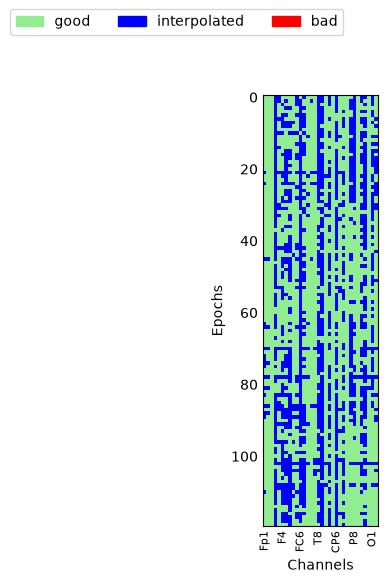

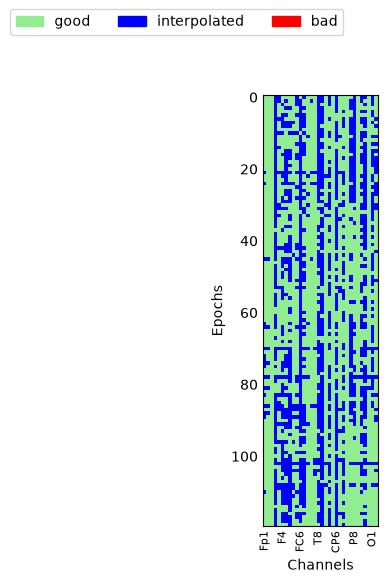

In [17]:
reject_log.plot()

## **Checking balance after rejection**

If AutoReject removes epochs unevenly across conditions, the permutation test remains valid but loses power in the most affected group.

In [18]:
balance = epochs_clean.metadata["condition"].value_counts()
print(balance)

if balance.max() - balance.min() > 0.2 * balance.max():
    print()
    print("WARNING: imbalance greater than 20 percent between conditions")

condition
high    40
none    40
low     40
Name: count, dtype: int64


## **Pairing holding and fixation epochs**

A trial enters the spectral analysis only if both its holding and its fixation survived AutoReject. After this cell, row `i` of `epochs_hold` and row `i` of `epochs_fix` are the same trial.

In [19]:
fix_keys = []
for ii in range(len(epochs_fix_clean)):
    row = epochs_fix_clean.metadata.iloc[ii]
    fix_keys.append(row["run"] + "_" + str(row["trial"]))

keep_hold = []
keep_fix = []
for ii in range(len(epochs_clean)):
    row = epochs_clean.metadata.iloc[ii]
    key = row["run"] + "_" + str(row["trial"])
    if key in fix_keys:
        keep_hold.append(ii)
        keep_fix.append(fix_keys.index(key))

epochs_hold = epochs_clean[keep_hold]
epochs_fix = epochs_fix_clean[keep_fix]

# Sanity check, same run and trial on every row
same_run = list(epochs_hold.metadata["run"]) == list(epochs_fix.metadata["run"])
same_trial = list(epochs_hold.metadata["trial"]) == list(epochs_fix.metadata["trial"])
if not (same_run and same_trial):
    raise ValueError("Holding and fixation epochs are not paired")

print(f"Paired trials: {len(epochs_hold)}")
print(epochs_hold.metadata["condition"].value_counts())

Paired trials: 120
condition
high    40
none    40
low     40
Name: count, dtype: int64


# **Separation between none, low and high**

This is the section that answers the question directly. Three views of the same thing:
the central ROI with confidence intervals, the GFP, and the single trials.

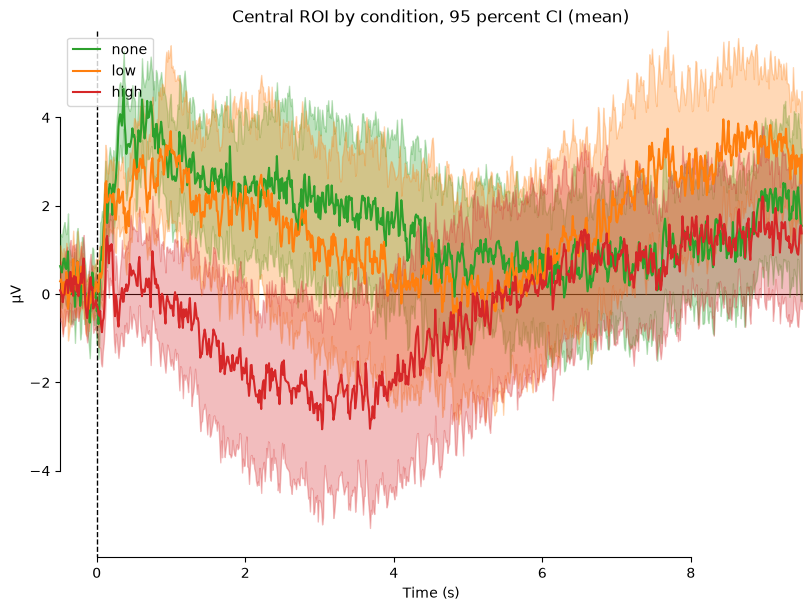

[<Figure size 800x600 with 1 Axes>]

In [20]:
central_roi = []
for name in CENTRAL_ROI:
    if name in epochs_clean.ch_names:
        central_roi.append(name)

by_condition = {}
for condition in ["none", "low", "high"]:
    by_condition[condition] = list(epochs_clean[f"condition == '{condition}'"].iter_evoked())

mne.viz.plot_compare_evokeds(
    by_condition,
    picks = central_roi,
    combine = "mean",
    colors = {"none": "tab:green", "low": "tab:orange", "high": "tab:red"},
    title = "Central ROI by condition, 95 percent CI",
)

# **1. The Spectrum and EpochsSpectrum classes**

Protocol: [MNE tutorial 10_spectrum_class](https://mne.tools/stable/auto_tutorials/time-freq/10_spectrum_class.html).

**Adaptation to this data.** The tutorial starts with `raw.compute_psd()`. That step is skipped: there is no single continuous `Raw` here (four runs were preprocessed separately and only their epochs were concatenated), and a spectrum of a whole run would mix fixation, inflating, holding, deflating and rating. The tutorial continues with `epochs.compute_psd()`, which gives an `EpochsSpectrum`, and that is the starting point here, restricted to the HOLDING window with `tmin` and `tmax`.

The default estimator for epochs is multitaper. On 9.5 s it uses 7 DPSS tapers with a smoothing of about 0.8 Hz.

In [21]:
hold_spectrum = epochs_hold.compute_psd(
    method = "multitaper",
    tmin = HOLD_TMIN,
    tmax = HOLD_TMAX,
    fmin = FMIN,
    fmax = FMAX,
    picks = "eeg",
)

psds, freqs = hold_spectrum.get_data(return_freqs = True)
print(f"PSDs shape: {psds.shape}, freqs shape: {freqs.shape}")
hold_spectrum

PSDs shape: (120, 32, 361), freqs shape: (361,)


<Power Spectrum (from Epochs, multitaper method) | 120 epochs × 32 channels × 361 freqs, 2.1-40.0 Hz>

## **Selecting spectra by condition**

The `EpochsSpectrum` inherits the metadata of `epochs_hold`, so the three conditions are selected with pandas query strings, exactly as in the tutorial's hint.

The tutorial also shows a `Spectrum` computed from an `Evoked`. That is not used here: averaging the time series first cancels every oscillation that is not phase-locked to the onset, and a tonic 10 s stimulus produces mostly non-phase-locked changes. `EpochsSpectrum.average()` averages the power instead, and gives the same `Spectrum` class with the same indexing.

In [22]:
spectrum_by_condition = {}

for condition in CONDITIONS:
    spectrum_by_condition[condition] = hold_spectrum[f"condition == '{condition}'"]
    print(condition, "->", len(spectrum_by_condition[condition]), "epochs")

# Spectrum indexing, as in the tutorial: first 3 frequency bins of the first 4 channels
mean_high = spectrum_by_condition["high"].average()
print()
print(mean_high.ch_names[:4])
print(mean_high[:4, :3])

none -> 40 epochs
low -> 40 epochs
high -> 40 epochs

['Fp1', 'Fp2', 'F7', 'F3']
[[2.06204855e-10 1.90531931e-10 1.68228342e-10]
 [1.58072285e-10 1.48936948e-10 1.23023773e-10]
 [4.09729022e-10 3.66286157e-10 3.07565747e-10]
 [1.61001005e-10 1.47876764e-10 1.26285641e-10]]


## **Visualizing Spectrum objects**

`plot()` (frequency x power, one line per channel), `plot_topo()` (one spectrum per sensor position) and `plot_topomap()` (band power on the scalp). The butterfly plot is drawn per condition. The topographic plots are drawn first for all holding epochs, as in the tutorial.

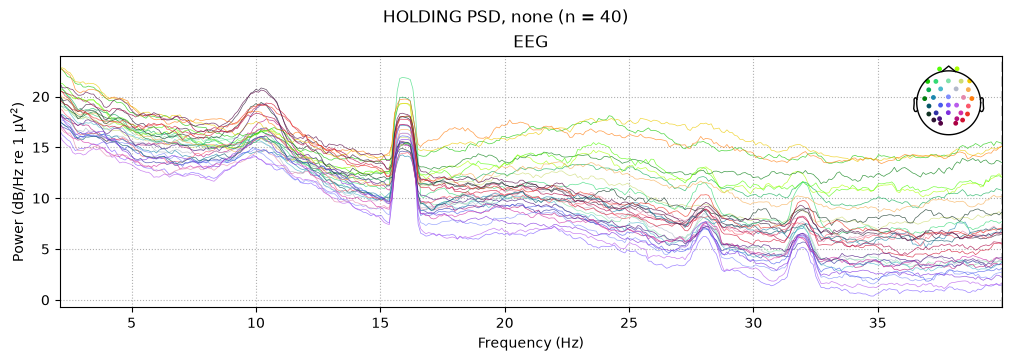

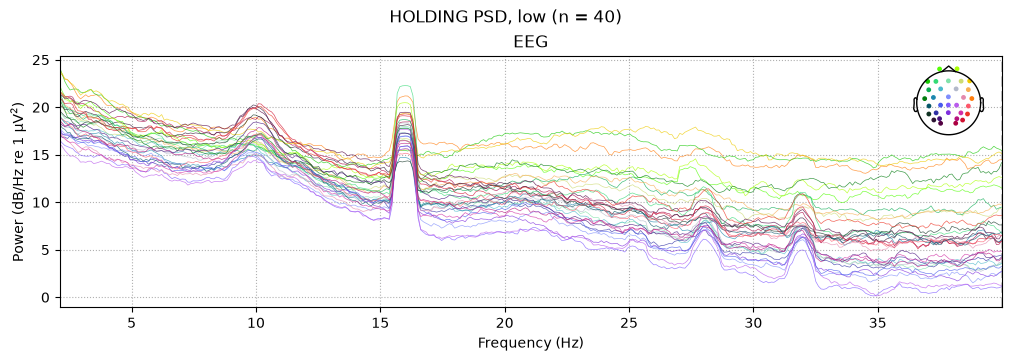

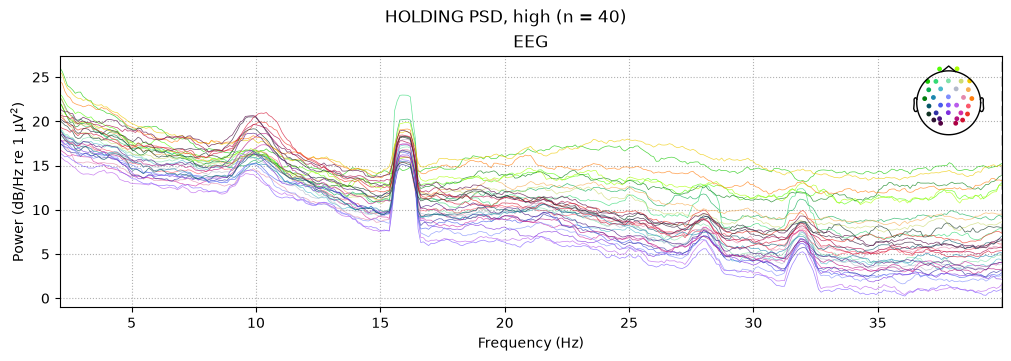

In [23]:
for condition in CONDITIONS:
    n_epochs = len(spectrum_by_condition[condition])
    fig = spectrum_by_condition[condition].plot(picks = "data", exclude = "bads", amplitude = False, show = False)
    fig.suptitle(f"HOLDING PSD, {condition} (n = {n_epochs})")
    plt.show()

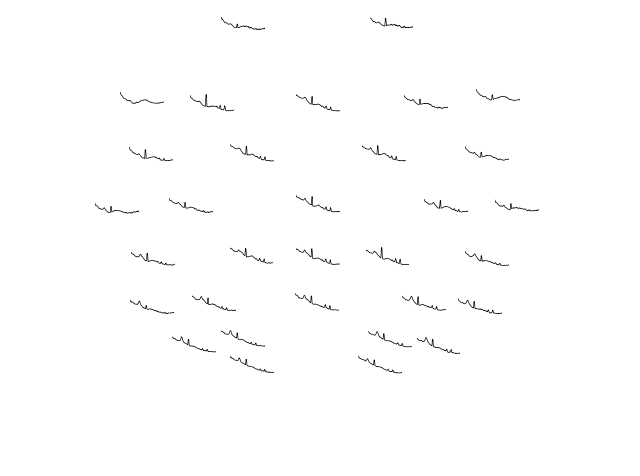

In [24]:
fig = hold_spectrum.plot_topo(color = "k", fig_facecolor = "w", axis_facecolor = "w")

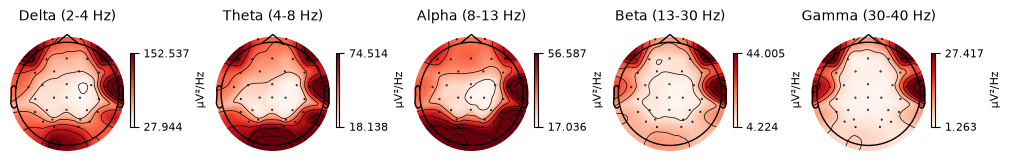

In [25]:
fig = hold_spectrum.plot_topomap(bands = BANDS, ch_type = "eeg", agg_fun = np.median)

## **Band topographies by condition on a common scale**

`plot_topomap` scales each figure on its own, so three separate calls cannot be compared by eye. Here the band power (median over the frequency bins of the band, mean over epochs, in dB) is drawn with one color scale per band shared by none, low and high.

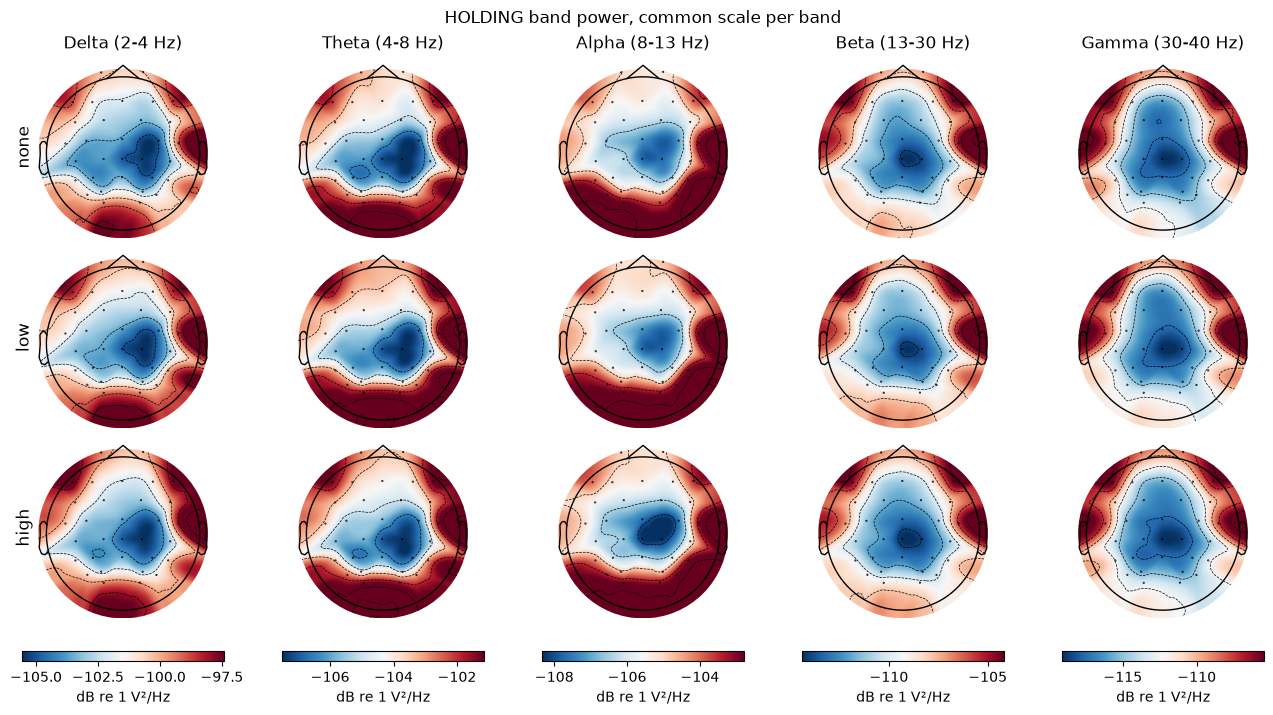

In [26]:
band_db = {}
for condition in CONDITIONS:
    band_db[condition] = {}
    for band_name in BANDS:
        fmin_band, fmax_band = BANDS[band_name]
        data = spectrum_by_condition[condition].get_data(fmin = fmin_band, fmax = fmax_band)
        # epochs x channels x freqs -> channels
        band_power = np.median(data, axis = 2).mean(axis = 0)
        band_db[condition][band_name] = 10 * np.log10(band_power)

fig, axes = plt.subplots(len(CONDITIONS), len(BANDS), figsize = (13, 7), layout = "constrained")

for jj in range(len(BANDS)):
    band_name = list(BANDS.keys())[jj]

    vmin = np.inf
    vmax = -np.inf
    for condition in CONDITIONS:
        vmin = min(vmin, band_db[condition][band_name].min())
        vmax = max(vmax, band_db[condition][band_name].max())

    for ii in range(len(CONDITIONS)):
        condition = CONDITIONS[ii]
        im, _ = mne.viz.plot_topomap(
            band_db[condition][band_name],
            hold_spectrum.info,
            axes = axes[ii, jj],
            vlim = (vmin, vmax),
            cmap = "RdBu_r",
            show = False,
        )
        if ii == 0:
            axes[ii, jj].set_title(band_name)
        if jj == 0:
            axes[ii, jj].set_ylabel(condition, fontsize = 12)

    fig.colorbar(im, ax = axes[:, jj], orientation = "horizontal", shrink = 0.8, label = "dB re 1 V²/Hz")

fig.suptitle("HOLDING band power, common scale per band")
plt.show()

# **2. Compute source power spectral density (PSD) in a label**

Returns a STC file containing the PSD (in dB) of each of the sources within a label.

Reference: [MNE example source_power_spectrum](https://mne.tools/stable/auto_examples/time_frequency/source_power_spectrum.html).

**Two steps of the example cannot be done as written with this data, so they are replaced:**

| Example | Problem here | Replacement |
| --- | --- | --- |
| `read_inverse_operator()` of the *sample* subject | There is no individual MRI and no digitized head shape | Template forward model on `fsaverage`, following [EEG forward operator with a template MRI](https://mne.tools/stable/auto_tutorials/forward/35_eeg_no_mri.html), and an inverse operator built from it |
| `compute_source_psd(raw, ..., dB=True)` | The data are concatenated epochs, not one `Raw` | `compute_source_psd_epochs()` per condition ([example](https://mne.tools/stable/auto_examples/time_frequency/compute_source_psd_epochs.html)), power averaged across epochs and then converted to dB, which is what `dB=True` does |

The noise covariance comes from the fixation epochs, the pre-stimulus period that is common to the three conditions. With a template head, absolute localization is approximate: read the label spectra as "activity best explained by postcentral cortex", not as an exact anatomical claim.

The first run of `fetch_fsaverage` downloads the template (about 200 MB) to `~/mne_data`. Reading the atlas labels needs `nibabel` (`pip install nibabel`).

In [27]:
fs_dir = fetch_fsaverage(verbose = False)
subjects_dir = fs_dir.parent

# MNE ships the fsaverage head <-> MRI transform
trans = "fsaverage"
src = fs_dir / "bem" / "fsaverage-ico-5-src.fif"
bem = fs_dir / "bem" / "fsaverage-5120-5120-5120-bem-sol.fif"

print(subjects_dir)

/Users/alberto/mne_data/MNE-fsaverage-data


## **Forward solution, noise covariance and inverse operator**

`epochs_hold.info` already carries the `standard_1020` montage set in `load_run` and the average reference projector, which the inverse operator requires for EEG.

In [28]:
fwd = mne.make_forward_solution(
    epochs_hold.info,
    trans = trans,
    src = src,
    bem = bem,
    eeg = True,
    meg = False,
    mindist = 5.0,
)
print(fwd)

noise_cov = mne.compute_covariance(epochs_fix, method = "shrunk", rank = None)

inverse_operator = make_inverse_operator(
    epochs_hold.info,
    fwd,
    noise_cov,
    loose = 0.2,
    depth = 0.8,
)
print(inverse_operator)

<Forward | MEG channels: 0 | EEG channels: 32 | Source space: Surface with 20484 vertices | Source orientation: Free>
<InverseOperator | MEG channels: 0 | EEG channels: 32 | Source space: surface with 20484 sources | Source orientation: Loose (0.2)>


In [29]:
all_labels = mne.read_labels_from_annot(SUBJECT, parc = "aparc", subjects_dir = subjects_dir)

labels = []
for label in all_labels:
    if label.name in LABEL_NAMES:
        labels.append(label)

for label in labels:
    print(label)

<Label | fsaverage, 'postcentral-lh', lh : 9519 vertices>
<Label | fsaverage, 'postcentral-rh', rh : 9138 vertices>


## **Compute the source PSD per label and condition**

One `.stc` pair (`-lh.stc`, `-rh.stc`) is written per label and condition. In these files `stc.times` holds the **frequencies** (Hz), not times, and `stc.data` is sources x frequencies in dB.

In [30]:
os.makedirs(STC_DIR, exist_ok = True)

stc_psd = {}

for label in labels:
    stc_psd[label.name] = {}

    for condition in CONDITIONS:
        epochs_condition = epochs_hold[f"condition == '{condition}'"].copy()
        epochs_condition.crop(tmin = HOLD_TMIN, tmax = HOLD_TMAX)

        stcs = compute_source_psd_epochs(
            epochs_condition,
            inverse_operator,
            lambda2 = LAMBDA2,
            method = INVERSE_METHOD,
            fmin = FMIN,
            fmax = FMAX,
            pick_ori = "normal",
            label = label,
            bandwidth = MT_BANDWIDTH,
            return_generator = True,
        )

        # Average the power across epochs first, dB afterwards
        power_sum = None
        n_epochs = 0
        for stc in stcs:
            if power_sum is None:
                stc_mean = stc
                power_sum = stc.data.copy()
            else:
                power_sum += stc.data
            n_epochs += 1

        stc_mean.data = 10 * np.log10(power_sum / n_epochs)

        fname = f"{STC_DIR}/psd_{INVERSE_METHOD}_{label.name}_{condition}"
        stc_mean.save(fname, overwrite = True)
        stc_psd[label.name][condition] = stc_mean

        print(f"{label.name} {condition}: {stc_mean.data.shape[0]} sources x {stc_mean.data.shape[1]} freqs, {n_epochs} epochs -> {fname}")

postcentral-lh none: 593 sources x 361 freqs, 40 epochs -> /Users/alberto/Desktop/dat/Files/stc_holding_psd/psd_dSPM_postcentral-lh_none
postcentral-lh low: 593 sources x 361 freqs, 40 epochs -> /Users/alberto/Desktop/dat/Files/stc_holding_psd/psd_dSPM_postcentral-lh_low
postcentral-lh high: 593 sources x 361 freqs, 40 epochs -> /Users/alberto/Desktop/dat/Files/stc_holding_psd/psd_dSPM_postcentral-lh_high
postcentral-rh none: 572 sources x 361 freqs, 40 epochs -> /Users/alberto/Desktop/dat/Files/stc_holding_psd/psd_dSPM_postcentral-rh_none
postcentral-rh low: 572 sources x 361 freqs, 40 epochs -> /Users/alberto/Desktop/dat/Files/stc_holding_psd/psd_dSPM_postcentral-rh_low
postcentral-rh high: 572 sources x 361 freqs, 40 epochs -> /Users/alberto/Desktop/dat/Files/stc_holding_psd/psd_dSPM_postcentral-rh_high


## **View the source PSD**

As in the example: one thin line per source of the label and the label mean in color. The last panel overlays the three label means.

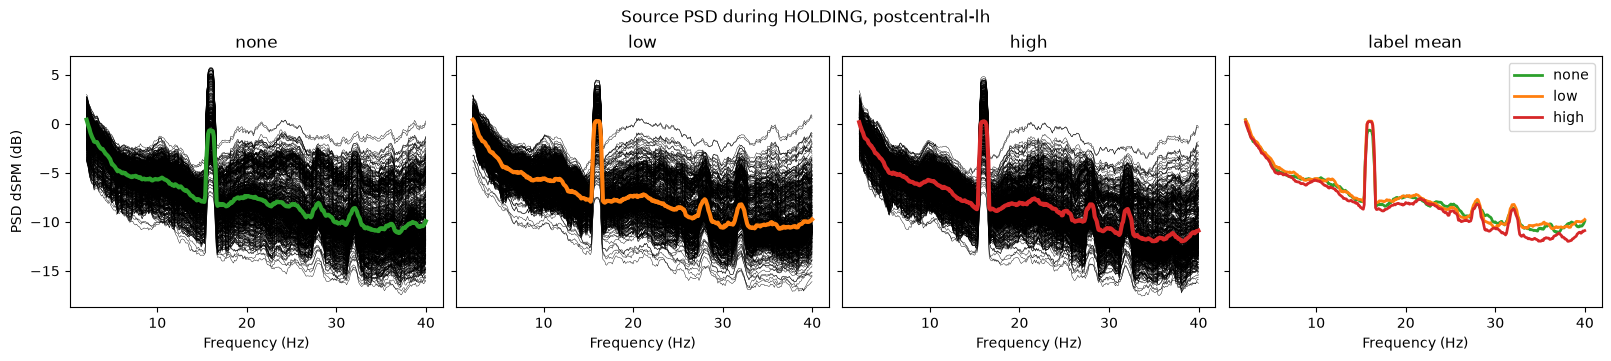

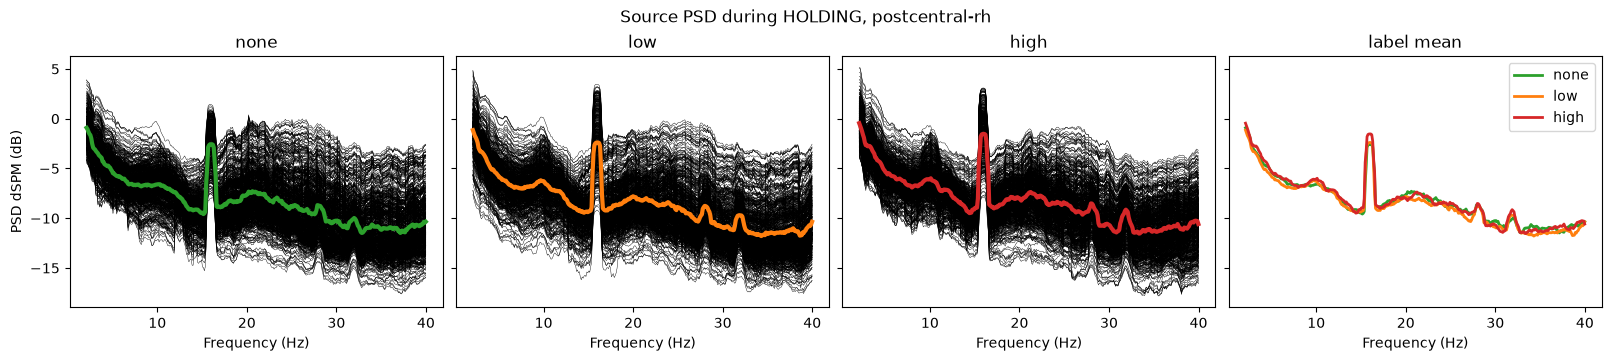

In [31]:
for label in labels:
    fig, axes = plt.subplots(1, len(CONDITIONS) + 1, figsize = (16, 3.5), sharey = True, layout = "constrained")

    for ii in range(len(CONDITIONS)):
        condition = CONDITIONS[ii]
        stc = stc_psd[label.name][condition]

        axes[ii].plot(stc.times, stc.data.T, "k", linewidth = 0.3)
        axes[ii].plot(stc.times, np.mean(stc.data, axis = 0), color = COLORS[condition], linewidth = 3)
        axes[ii].set(xlabel = "Frequency (Hz)", title = condition)

        axes[-1].plot(stc.times, np.mean(stc.data, axis = 0), color = COLORS[condition], linewidth = 2, label = condition)

    axes[0].set_ylabel(f"PSD {INVERSE_METHOD} (dB)")
    axes[-1].set(xlabel = "Frequency (Hz)", title = "label mean")
    axes[-1].legend()
    fig.suptitle(f"Source PSD during HOLDING, {label.name}")
    plt.show()

# **3. Frequency and time-frequency sensor analysis**

Protocol: [MNE tutorial 20_sensors_time_frequency](https://mne.tools/stable/auto_tutorials/time-freq/20_sensors_time_frequency.html).

## **Frequency analysis**

The first two plots of the tutorial, `compute_psd().plot(average=True)` and `compute_psd().plot_topomap()`, are the same computations already shown in section 1 on the same epochs, so they are not repeated. The tutorial's manual plot of the channel mean ± standard deviation is drawn here with the three conditions on one axis.

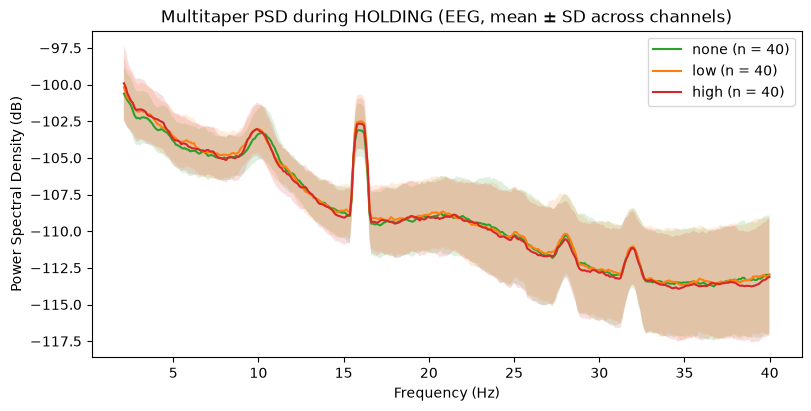

In [32]:
fig, ax = plt.subplots(figsize = (8, 4), layout = "constrained")

for condition in CONDITIONS:
    spectrum = epochs_hold[f"condition == '{condition}'"].compute_psd(
        fmin = FMIN, fmax = FMAX, tmin = HOLD_TMIN, tmax = HOLD_TMAX
    )
    # average across epochs first
    mean_spectrum = spectrum.average()
    psds, freqs = mean_spectrum.get_data(return_freqs = True)
    # then convert to dB and take mean & standard deviation across channels
    psds = 10 * np.log10(psds)
    psds_mean = psds.mean(axis = 0)
    psds_std = psds.std(axis = 0)

    ax.plot(freqs, psds_mean, color = COLORS[condition], label = f"{condition} (n = {len(spectrum)})")
    ax.fill_between(
        freqs,
        psds_mean - psds_std,
        psds_mean + psds_std,
        color = COLORS[condition],
        alpha = 0.15,
        edgecolor = "none",
    )

ax.set(
    title = "Multitaper PSD during HOLDING (EEG, mean ± SD across channels)",
    xlabel = "Frequency (Hz)",
    ylabel = "Power Spectral Density (dB)",
)
ax.legend(loc = "upper right")
plt.show()

`average='median'` in Welch gives a PSD that is robust to a single bad segment. The tutorial compares both on one sensor and one epoch.

On epochs, `compute_psd("welch")` uses by default one window as long as the whole epoch, which leaves a single segment and makes mean and median identical. `n_fft = 256` samples (3 s at 85.3 Hz) with 50 percent overlap splits each 9.5 s holding epoch into 5 segments, so the comparison means something.

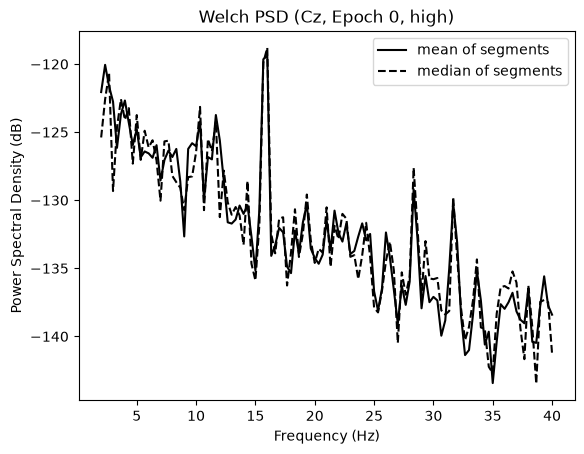

(120, 32, 115, 5)


In [33]:
# Estimate PSDs based on "mean" and "median" averaging for comparison.
kwargs = dict(fmin = FMIN, fmax = FMAX, tmin = HOLD_TMIN, tmax = HOLD_TMAX, n_fft = 256, n_overlap = 128, n_jobs = None)
psds_welch_mean, freqs_mean = epochs_hold.compute_psd("welch", average = "mean", **kwargs).get_data(return_freqs = True)
psds_welch_median, freqs_median = epochs_hold.compute_psd("welch", average = "median", **kwargs).get_data(return_freqs = True)

# Convert power to dB scale.
psds_welch_mean = 10 * np.log10(psds_welch_mean)
psds_welch_median = 10 * np.log10(psds_welch_median)

# We will only plot the PSD for a single sensor in the first epoch.
ch_name = "Cz"
ch_idx = epochs_hold.info["ch_names"].index(ch_name)
epo_idx = 0

_, ax = plt.subplots()
ax.plot(freqs_mean, psds_welch_mean[epo_idx, ch_idx, :], color = "k", ls = "-", label = "mean of segments")
ax.plot(freqs_median, psds_welch_median[epo_idx, ch_idx, :], color = "k", ls = "--", label = "median of segments")
ax.set(
    title = f"Welch PSD ({ch_name}, Epoch {epo_idx}, {epochs_hold.metadata['condition'].iloc[epo_idx]})",
    xlabel = "Frequency (Hz)",
    ylabel = "Power Spectral Density (dB)",
)
ax.legend(loc = "upper right")
plt.show()

# Unaggregated segments: (n_epochs, n_sensors, n_freqs, n_segments)
welch_unagg = epochs_hold.compute_psd("welch", average = None, **kwargs)
print(welch_unagg.shape)

## **Time-frequency analysis: power and inter-trial coherence**

Morlet TFR of the averaged power and the ITC, per condition, with `n_cycles = freqs / 2` as in the tutorial.

**Baseline.** The tutorial uses `baseline=(-0.5, 0), mode="logratio"`. As explained in *Fixation reference of each holding event*, the 0.5 s before HOLDING are INFLATING, their content depends on the condition, and they sit inside the wavelet edge. The same `logratio` is applied, but against the fixation of the same condition:

$$\text{power}_{dB\text{-like}}(f, t) = \log_{10}\frac{P_{\text{hold}}(f, t)}{\overline{P_{\text{fix}}}(f)}$$

where $\overline{P_{\text{fix}}}(f)$ is the averaged fixation power from 0.5 to 2.5 s. The tutorial's baseline note says single-trial `logratio` is biased, and averaged `AverageTFR` much less, so here the ratio is taken after averaging. A value of 0 means same power as fixation, -0.1 means about 21 percent less.

In [34]:
def fixation_logratio(power, fix_power):
    """log10 of the holding power divided by the mean fixation power, per channel and frequency."""
    in_window = (fix_power.times >= FIX_BASE_TMIN) & (fix_power.times <= FIX_BASE_TMAX)
    reference = fix_power.data[:, :, in_window].mean(axis = 2)
    ratio = power.data / reference[:, :, np.newaxis]

    return mne.time_frequency.AverageTFRArray(
        info = power.info,
        data = np.log10(ratio),
        times = power.times,
        freqs = power.freqs,
        nave = power.nave,
        comment = power.comment,
        method = "morlet",
    )


power_by_condition = {}
itc_by_condition = {}

for condition in CONDITIONS:
    query = f"condition == '{condition}'"

    power, itc = epochs_hold[query].compute_tfr(
        method = "morlet",
        freqs = TFR_FREQS,
        n_cycles = TFR_N_CYCLES,
        average = True,
        return_itc = True,
        decim = TFR_DECIM,
    )
    fix_power = epochs_fix[query].compute_tfr(
        method = "morlet",
        freqs = TFR_FREQS,
        n_cycles = TFR_N_CYCLES,
        average = True,
        return_itc = False,
        decim = TFR_DECIM,
    )

    # Drop the INFLATING samples and the wavelet edges
    power.crop(tmin = TFR_TMIN, tmax = TFR_TMAX)
    itc.crop(tmin = TFR_TMIN, tmax = TFR_TMAX)

    power_by_condition[condition] = fixation_logratio(power, fix_power)
    itc_by_condition[condition] = itc

    print(condition, power_by_condition[condition])

# One symmetric color scale for all power plots, robust to a few extreme points
all_values = []
for condition in CONDITIONS:
    all_values.append(np.abs(power_by_condition[condition].data).ravel())
VLIM_POWER = float(np.percentile(np.concatenate(all_values), 99))
print("color limit:", round(VLIM_POWER, 3))

none <TFR from Evoked (nave=40), morlet method | 32 channels × 19 freqs × 194 times, 4.0 - 40.0 Hz, -0.02 - 9.02 s, 964 KiB>
low <TFR from Evoked (nave=40), morlet method | 32 channels × 19 freqs × 194 times, 4.0 - 40.0 Hz, -0.02 - 9.02 s, 964 KiB>
high <TFR from Evoked (nave=40), morlet method | 32 channels × 19 freqs × 194 times, 4.0 - 40.0 Hz, -0.02 - 9.02 s, 964 KiB>
color limit: 0.453


## **Inspect power**

The figures are interactive in a Jupyter backend such as `%matplotlib widget`: in the topo you can click a sensor to open its TFR.

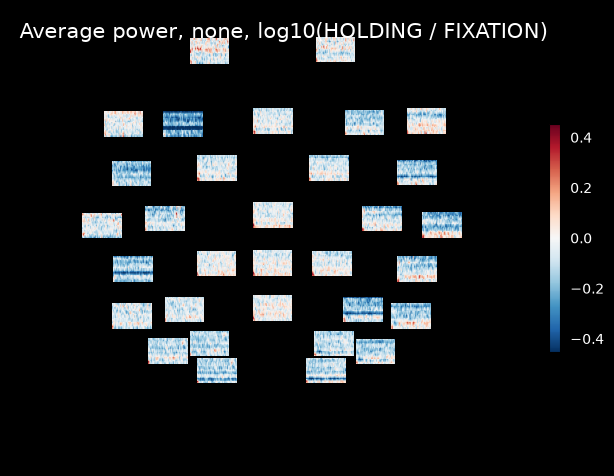

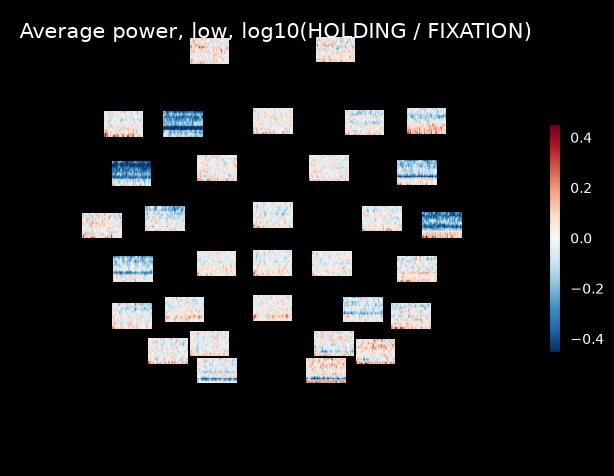

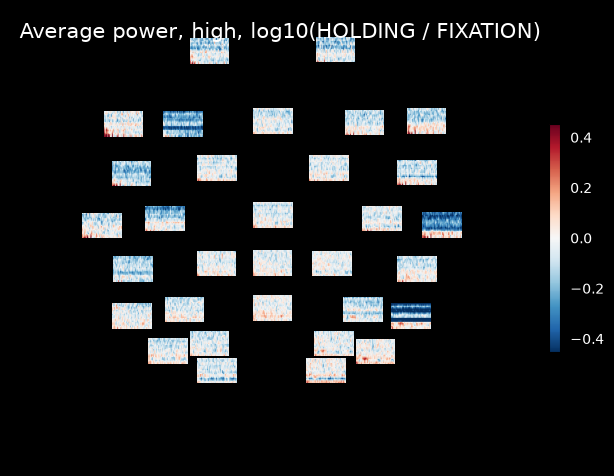

In [35]:
for condition in CONDITIONS:
    power_by_condition[condition].plot_topo(
        baseline = None,
        vmin = -VLIM_POWER,
        vmax = VLIM_POWER,
        title = f"Average power, {condition}, log10(HOLDING / FIXATION)",
    )

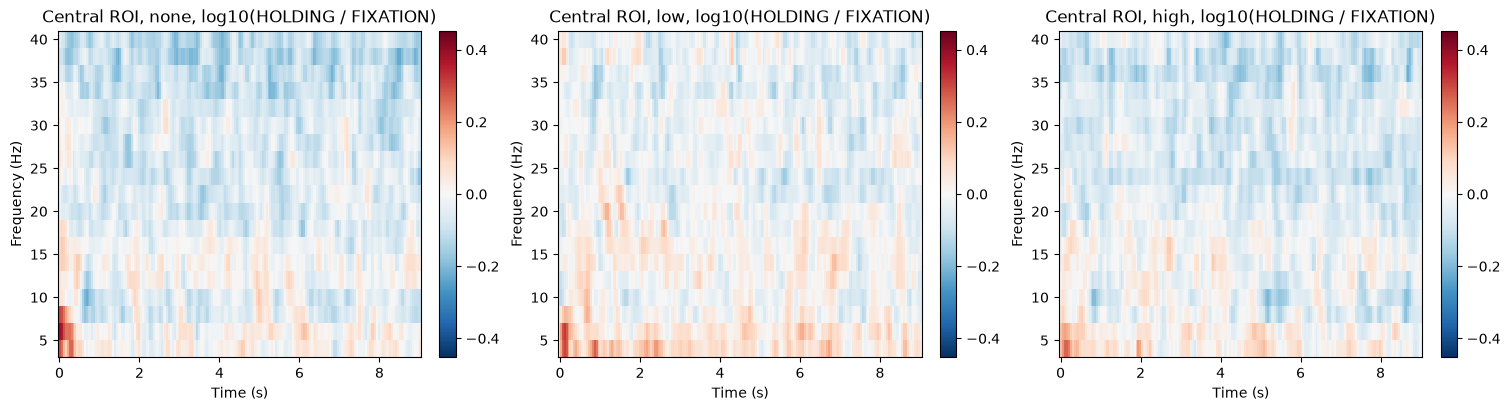

In [36]:
central_roi = []
for name in CENTRAL_ROI:
    if name in epochs_hold.ch_names:
        central_roi.append(name)

fig, axes = plt.subplots(1, len(CONDITIONS), figsize = (15, 4), layout = "constrained")

for ii in range(len(CONDITIONS)):
    condition = CONDITIONS[ii]
    power_by_condition[condition].plot(
        picks = central_roi,
        combine = "mean",
        baseline = None,
        vlim = (-VLIM_POWER, VLIM_POWER),
        axes = axes[ii],
        show = False,
    )
    axes[ii].set_title(f"Central ROI, {condition}, log10(HOLDING / FIXATION)")

plt.show()

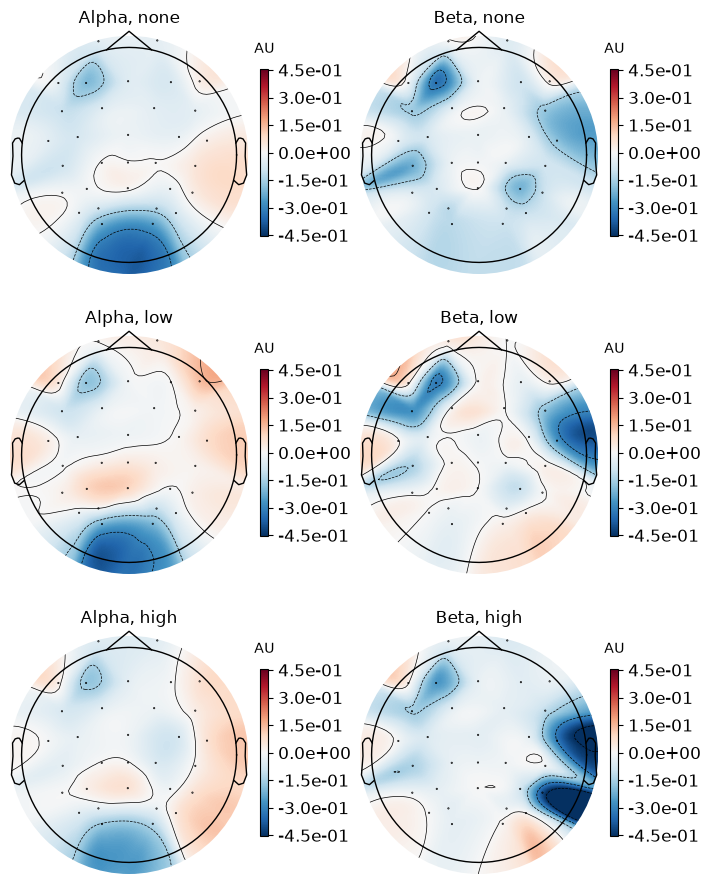

In [37]:
plot_dict = dict(Alpha = dict(fmin = 8, fmax = 12), Beta = dict(fmin = 13, fmax = 25))

fig, axes = plt.subplots(len(CONDITIONS), len(plot_dict), figsize = (7, 9), layout = "constrained")

for jj in range(len(plot_dict)):
    title = list(plot_dict.keys())[jj]
    fmin_fmax = plot_dict[title]

    for ii in range(len(CONDITIONS)):
        condition = CONDITIONS[ii]
        power_by_condition[condition].plot_topomap(
            ch_type = "eeg",
            tmin = TFR_TMIN,
            tmax = TFR_TMAX,
            baseline = None,
            vlim = (-VLIM_POWER, VLIM_POWER),
            axes = axes[ii, jj],
            show = False,
            **fmin_fmax,
        )
        axes[ii, jj].set_title(f"{title}, {condition}")

plt.show()

## **Joint Plot**

Aggregated TFR across channels with topomaps at chosen time-frequency points: alpha early and mid-hold, and beta mid-hold.

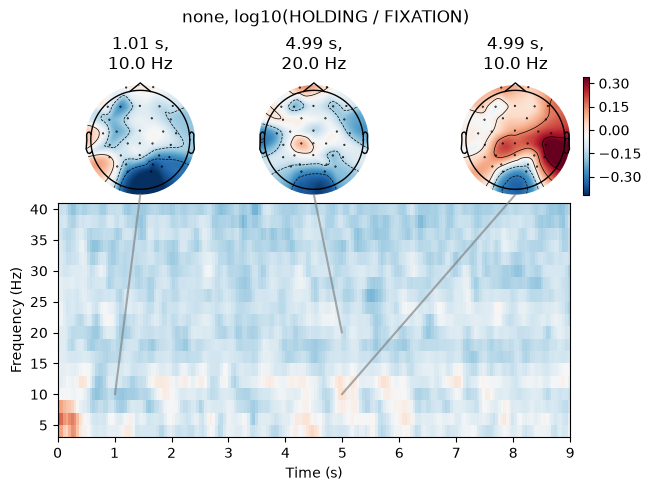

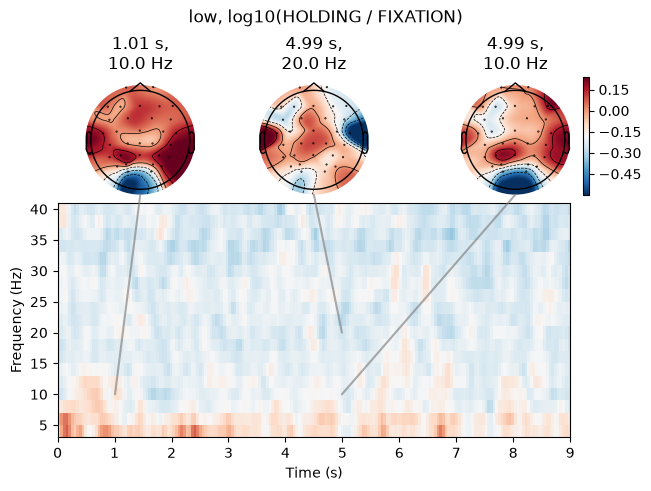

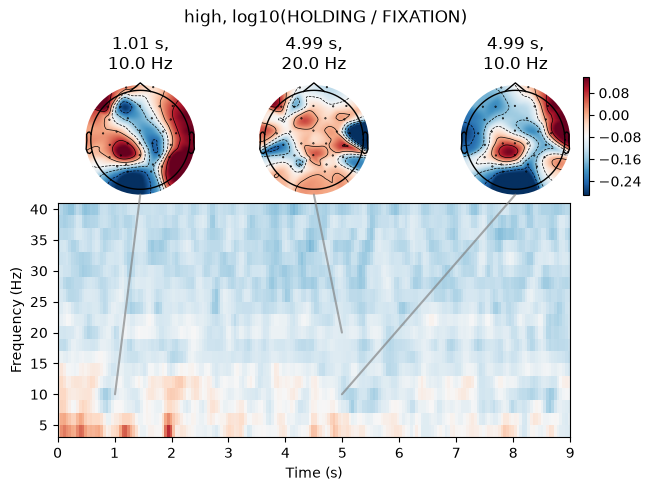

In [38]:
for condition in CONDITIONS:
    power_by_condition[condition].plot_joint(
        baseline = None,
        mode = "mean",
        tmin = TFR_TMIN,
        tmax = TFR_TMAX,
        timefreqs = [(1.0, 10), (5.0, 10), (5.0, 20)],
        vlim = (-VLIM_POWER, VLIM_POWER),
        title = f"{condition}, log10(HOLDING / FIXATION)",
    )

## **Inspect ITC**

ITC measures phase locking to the HOLDING onset. With about 40 trials per condition, values below roughly $1/\sqrt{40} \approx 0.16$ are at the noise floor, so the color scale is capped at 0.5 instead of the tutorial's 1.0 to keep the structure visible.

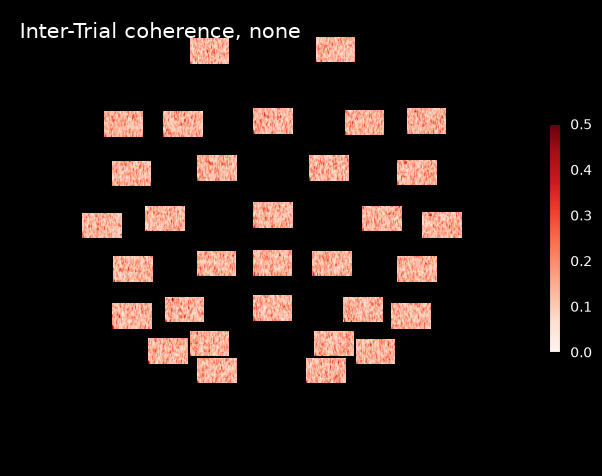

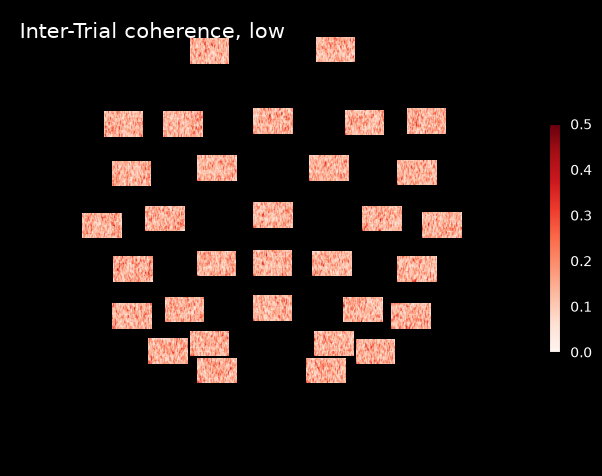

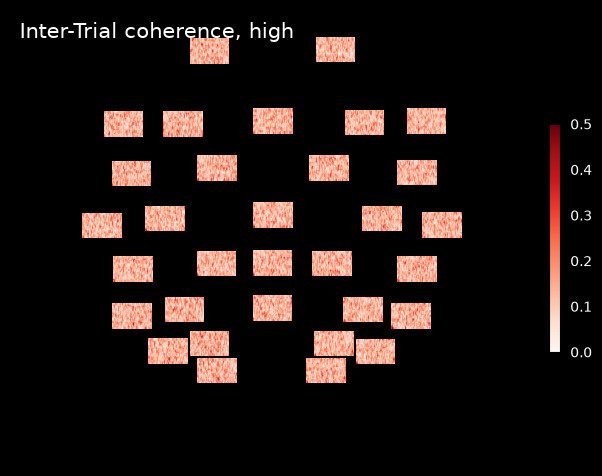

In [39]:
for condition in CONDITIONS:
    itc_by_condition[condition].plot_topo(
        title = f"Inter-Trial coherence, {condition}",
        vmin = 0.0,
        vmax = 0.5,
        cmap = "Reds",
    )

# **4. Non-parametric between conditions cluster statistic on single trial power**

Protocol: [MNE tutorial 50_cluster_between_time_freq](https://mne.tools/stable/auto_tutorials/stats-sensor-space/50_cluster_between_time_freq.html).

The procedure of the tutorial:

- extracting epochs for the conditions
- compute single trial power estimates
- baseline correct the power estimates (power ratios)
- compute stats to see if the power estimates are significantly different between conditions

**Adaptations.**

1. **Three conditions.** `permutation_cluster_test` receives `[none, low, high]` and its default statistic becomes a one-way F test across the three groups (the tutorial with two groups is the same F test with 1 numerator degree of freedom). The omnibus test says *whether* the conditions differ. The tutorial's two-condition test is then run for each pair, with Bonferroni correction (alpha 0.05 / 3), to say *which* ones.
2. **Baseline.** `mode="ratio"` as in the tutorial, but the reference of each trial is **its own fixation** (mean power 0.5 to 2.5 s), for the reasons given above.
3. **Channel.** The tutorial restricts the test to one channel. Here the single-trial ratio is averaged over `STATS_PICKS` (central ROI), which is more stable on a 32-channel EEG. Set `STATS_PICKS = ["C3"]` to test one channel.
4. **Threshold.** The tutorial fixes `threshold = 6.0`. With three groups the degrees of freedom change, so the cluster-forming threshold is taken from the F distribution at `P_CLUSTER`.

The trials are independent observations from one participant, so this is a within-subject, trial-level test, the same design as the tutorial.

In [40]:
stats_picks = []
for name in STATS_PICKS:
    if name in epochs_hold.ch_names:
        stats_picks.append(name)

tfr_kwargs = dict(
    method = "morlet",
    freqs = TFR_FREQS,
    n_cycles = TFR_N_CYCLES,
    decim = TFR_DECIM,
    return_itc = False,
    average = False,
    picks = stats_picks,
)

tfr_epochs_hold = epochs_hold.compute_tfr(**tfr_kwargs)
tfr_epochs_fix = epochs_fix.compute_tfr(**tfr_kwargs)

tfr_epochs_hold.crop(tmin = TFR_TMIN, tmax = TFR_TMAX)

# Single-trial ratio against the fixation of the same trial
in_window = (tfr_epochs_fix.times >= FIX_BASE_TMIN) & (tfr_epochs_fix.times <= FIX_BASE_TMAX)
fix_reference = tfr_epochs_fix.data[:, :, :, in_window].mean(axis = 3)
ratio = tfr_epochs_hold.data / fix_reference[:, :, :, np.newaxis]

# Average over the ROI channels: epochs x freqs x times
roi_ratio = ratio.mean(axis = 1)

# Kept only for the figures: ROI power of each trial and its fixation reference
roi_hold_power = tfr_epochs_hold.data.mean(axis = 1)
roi_fix_reference = fix_reference.mean(axis = 1)

conditions_array = epochs_hold.metadata["condition"].to_numpy()
epochs_power = {}
for condition in CONDITIONS:
    epochs_power[condition] = roi_ratio[conditions_array == condition]
    print(condition, epochs_power[condition].shape)

times = tfr_epochs_hold.times
freqs = tfr_epochs_hold.freqs

none (40, 19, 194)
low (40, 19, 194)
high (40, 19, 194)


## **Compute statistic: omnibus F test, none vs low vs high**

In [41]:
def summarize_clusters(test_name, clusters, cluster_p_values, alpha, power_a = None, power_b = None, names = None):
    rows = []
    for ii in range(len(clusters)):
        mask = clusters[ii]
        freq_idx = np.where(mask.any(axis = 1))[0]
        time_idx = np.where(mask.any(axis = 0))[0]

        row = {
            "test": test_name,
            "cluster": ii,
            "p_value": float(cluster_p_values[ii]),
            "significant": bool(cluster_p_values[ii] <= alpha),
            "t_start_s": round(float(times[time_idx[0]]), 2),
            "t_end_s": round(float(times[time_idx[-1]]), 2),
            "f_low_hz": float(freqs[freq_idx[0]]),
            "f_high_hz": float(freqs[freq_idx[-1]]),
            "n_tf_points": int(mask.sum()),
        }

        # Direction of the effect, only defined for two groups
        if power_a is not None:
            difference = power_a.mean(axis = 0) - power_b.mean(axis = 0)
            if difference[mask].mean() > 0:
                row["higher_in"] = names[0]
            else:
                row["higher_in"] = names[1]

        rows.append(row)
    return rows


n_obs = 0
for condition in CONDITIONS:
    n_obs += len(epochs_power[condition])

dfn = len(CONDITIONS) - 1
dfd = n_obs - len(CONDITIONS)
threshold = stats.f.ppf(1.0 - P_CLUSTER, dfn, dfd)
print(f"F({dfn}, {dfd}) cluster-forming threshold at p = {P_CLUSTER}: {threshold:.2f}")

# tail = 1 because F is one-sided. The tutorial passes tail = 0 and MNE switches it to 1 internally.
F_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(
    [epochs_power["none"], epochs_power["low"], epochs_power["high"]],
    out_type = "mask",
    n_permutations = N_PERMUTATIONS,
    threshold = threshold,
    tail = 1,
    rng = np.random.default_rng(seed = SEED),
)

cluster_rows = summarize_clusters("none vs low vs high", clusters, cluster_p_values, ALPHA)

n_significant = 0
for row in cluster_rows:
    if row["significant"]:
        n_significant += 1
print(f"{len(clusters)} clusters, {n_significant} with p <= {ALPHA}")

F(2, 117) cluster-forming threshold at p = 0.01: 4.79


TypeError: permutation_cluster_test() got an unexpected keyword argument 'rng'

In [ ]:
fig, axes = plt.subplots(1, len(CONDITIONS) + 1, figsize = (17, 3.8), layout = "constrained")
extent = [times[0], times[-1], freqs[0], freqs[-1]]

# Condition means for context. The mean of single-trial ratios is pulled upwards by
# their skewed distribution, so the figure shows the ratio of the mean powers instead.
mean_db = {}
vlim_db = 0.0
for condition in CONDITIONS:
    in_condition = conditions_array == condition
    mean_hold = roi_hold_power[in_condition].mean(axis = 0)
    mean_fix = roi_fix_reference[in_condition].mean(axis = 0)
    mean_db[condition] = 10 * np.log10(mean_hold / mean_fix[:, np.newaxis])
    vlim_db = max(vlim_db, float(np.percentile(np.abs(mean_db[condition]), 99)))

for ii in range(len(CONDITIONS)):
    condition = CONDITIONS[ii]
    im = axes[ii].imshow(mean_db[condition], extent = extent, aspect = "auto", origin = "lower", cmap = "RdBu_r", vmin = -vlim_db, vmax = vlim_db)
    axes[ii].set(title = f"{condition}: HOLDING / FIXATION", xlabel = "Time (s)", ylabel = "Frequency (Hz)")
fig.colorbar(im, ax = axes[:len(CONDITIONS)], label = "dB", shrink = 0.9)

# Create new stats image with only significant clusters
F_obs_plot = np.nan * np.ones_like(F_obs)
for c, p_val in zip(clusters, cluster_p_values):
    if p_val <= ALPHA:
        F_obs_plot[c] = F_obs[c]

ax = axes[-1]
ax.imshow(F_obs, extent = extent, aspect = "auto", origin = "lower", cmap = "gray")
if np.any(~np.isnan(F_obs_plot)):
    ax.imshow(F_obs_plot, extent = extent, aspect = "auto", origin = "lower", cmap = "Reds", vmin = 0, vmax = np.nanmax(F_obs_plot))
ax.set(title = "F, significant clusters in red", xlabel = "Time (s)", ylabel = "Frequency (Hz)")

fig.suptitle(f"Induced power ({', '.join(stats_picks)})")
plt.show()

## **Compute statistic: pairwise tests**

The tutorial's two-condition test, run for each pair. The sign of the mean difference inside each cluster is added to the F map, as in the tutorial, so red means higher power in the first condition of the pair and blue in the second. A cluster is significant at p <= 0.05 / 3.

In [ ]:
alpha_pair = ALPHA / len(PAIRS)

for pair in PAIRS:
    name_1, name_2 = pair
    epochs_power_1 = epochs_power[name_1]
    epochs_power_2 = epochs_power[name_2]

    dfd_pair = len(epochs_power_1) + len(epochs_power_2) - 2
    threshold_pair = stats.f.ppf(1.0 - P_CLUSTER, 1, dfd_pair)

    F_obs, clusters, cluster_p_values, H0 = permutation_cluster_test(
        [epochs_power_1, epochs_power_2],
        out_type = "mask",
        n_permutations = N_PERMUTATIONS,
        threshold = threshold_pair,
        tail = 1,
        rng = np.random.default_rng(seed = SEED),
    )

    test_name = f"{name_1} vs {name_2}"
    cluster_rows += summarize_clusters(
        test_name, clusters, cluster_p_values, alpha_pair,
        power_a = epochs_power_1, power_b = epochs_power_2, names = pair,
    )

    # View time-frequency plots
    fig, (ax, ax2) = plt.subplots(2, 1, figsize = (7, 5), layout = "constrained")

    # Compute the difference in evoked to determine which was greater since
    # we used a 1-way ANOVA which tested for a difference in population means
    evoked_power_1 = epochs_power_1.mean(axis = 0)
    evoked_power_2 = epochs_power_2.mean(axis = 0)
    evoked_power_contrast = evoked_power_1 - evoked_power_2
    signs = np.sign(evoked_power_contrast)

    # Create new stats image with only significant clusters
    F_obs_plot = np.nan * np.ones_like(F_obs)
    for c, p_val in zip(clusters, cluster_p_values):
        if p_val <= alpha_pair:
            F_obs_plot[c] = F_obs[c] * signs[c]

    ax.imshow(F_obs, extent = extent, aspect = "auto", origin = "lower", cmap = "gray")
    if np.any(~np.isnan(F_obs_plot)):
        max_F = np.nanmax(abs(F_obs_plot))
        ax.imshow(F_obs_plot, extent = extent, aspect = "auto", origin = "lower", cmap = "RdBu_r", vmin = -max_F, vmax = max_F)

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (Hz)")
    ax.set_title(f"Induced power ({', '.join(stats_picks)}), {test_name}")

    # plot evoked
    evoked_condition_1 = epochs_hold[f"condition == '{name_1}'"].average(picks = stats_picks)
    evoked_condition_2 = epochs_hold[f"condition == '{name_2}'"].average(picks = stats_picks)
    evoked_contrast = mne.combine_evoked([evoked_condition_1, evoked_condition_2], weights = [1, -1])
    evoked_contrast.plot(axes = ax2, time_unit = "s", show = False)
    ax2.set_xlim(times[0], times[-1])
    ax2.set_title(f"Evoked contrast {name_1} - {name_2}")

    plt.show()

## **Cluster summary**

Every cluster found by the four tests, with its p-value, its time-frequency extent and, for the pairwise tests, the condition with more power. `significant` uses 0.05 for the omnibus test and 0.05 / 3 for the pairs.

In [ ]:
clusters_df = pd.DataFrame(cluster_rows)
clusters_df.to_csv(f"{STC_DIR}/cluster_summary.csv", index = False)
clusters_df.sort_values(["test", "p_value"])